# VFA-1 — Linear Function Approximation Experiment

Trains a `LinearFAAgent` on a 10×10 `FogGridWorld` for 5 000 episodes and compares
it directly against a `TabularQAgent` trained on the **same** sequence of random maps.

**Scientific question:** does linear FA generalise better than tabular Q-learning
when every episode presents a fresh random layout?

This notebook covers:
1. Training both agents
2. Learning-curve comparison
3. Learned-weight interpretation

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.environment.grid_world import FogGridWorld
from src.agents.tabular_q import TabularQAgent
from src.agents.linear_fa import LinearFAAgent
from src.features.feature_extractor import N_FEATURES

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Train both agents

Both agents train on the **same** environment object so they encounter identical
random map sequences (seeded by NumPy's default RNG).
Each episode resets with a fresh random layout — memorisation is impossible.

Hyperparameters follow the VFA-1 design spec:
- Tabular: `alpha=0.1` (higher — table entries are independent)
- Linear FA: `alpha=0.01` (lower — a single theta update affects *all* states)

In [2]:
N_TRAIN = 5000
GRID    = 10
SMOOTH  = 50   # rolling-average window for learning curves

env = FogGridWorld(grid_size=GRID)

# ── Tabular Q-Learning ────────────────────────────────────────────────────────
agent_q = TabularQAgent(
    n_actions     = env.action_space.n,
    alpha         = 0.1,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
)

q_rewards:   list[float] = []
q_table_sizes: list[int] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward = 0.0
    done = False

    while not done:
        action = agent_q.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_q.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated

    agent_q.decay_epsilon()
    q_rewards.append(ep_reward)
    q_table_sizes.append(agent_q.q_table_size)

    if ep % 1000 == 0:
        avg = float(np.mean(q_rewards[-100:]))
        print(
            f'[Tabular] ep {ep:>5}  '
            f'avg_reward(100) {avg:+.3f}  '
            f'eps {agent_q.epsilon:.3f}  '
            f'Q-entries {agent_q.q_table_size:,}'
        )

[Tabular] ep  1000  avg_reward(100) -1.744  eps 0.050  Q-entries 179,112
[Tabular] ep  2000  avg_reward(100) -1.786  eps 0.050  Q-entries 342,373
[Tabular] ep  3000  avg_reward(100) -1.612  eps 0.050  Q-entries 491,712
[Tabular] ep  4000  avg_reward(100) -1.408  eps 0.050  Q-entries 630,250
[Tabular] ep  5000  avg_reward(100) -1.347  eps 0.050  Q-entries 764,370


In [3]:
# ── Linear Function Approximation ─────────────────────────────────────────────
agent_fa = LinearFAAgent(
    n_actions     = env.action_space.n,
    max_steps     = env.max_steps,
    alpha         = 0.01,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
)

fa_rewards: list[float] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward = 0.0
    done = False

    while not done:
        action = agent_fa.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_fa.update(obs, action, reward, next_obs, terminated, truncated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated

    agent_fa.decay_epsilon()
    fa_rewards.append(ep_reward)

    if ep % 1000 == 0:
        avg = float(np.mean(fa_rewards[-100:]))
        print(
            f'[Linear FA] ep {ep:>5}  '
            f'avg_reward(100) {avg:+.3f}  '
            f'eps {agent_fa.epsilon:.3f}  '
            f'theta {np.round(agent_fa.theta, 3)}'
        )

[Linear FA] ep  1000  avg_reward(100) -0.849  eps 0.050  theta [-0.021  0.096 -0.568  0.028 -0.261]
[Linear FA] ep  2000  avg_reward(100) -0.948  eps 0.050  theta [-0.018  0.047 -0.608 -0.001 -0.282]
[Linear FA] ep  3000  avg_reward(100) -0.971  eps 0.050  theta [-0.018  0.044 -0.629  0.004 -0.233]
[Linear FA] ep  4000  avg_reward(100) -0.905  eps 0.050  theta [-0.02   0.067 -0.599  0.021 -0.273]
[Linear FA] ep  5000  avg_reward(100) -0.879  eps 0.050  theta [-0.021  0.116 -0.606  0.006 -0.256]


## 2. Learning-curve comparison

Both curves are smoothed with a 50-episode rolling average.

**Expected pattern:**
- Tabular Q plateaus or degrades as the Q-table fills with state-specific entries
  that never generalise to new map layouts.
- Linear FA converges to a higher (less negative) average reward because `phi(s, a)`
  encodes structure that transfers across episodes: wall proximity, goal visibility,
  energy level.

The bottom panel shows the explosive growth of the tabular Q-table — a direct proxy
for the curse of dimensionality.

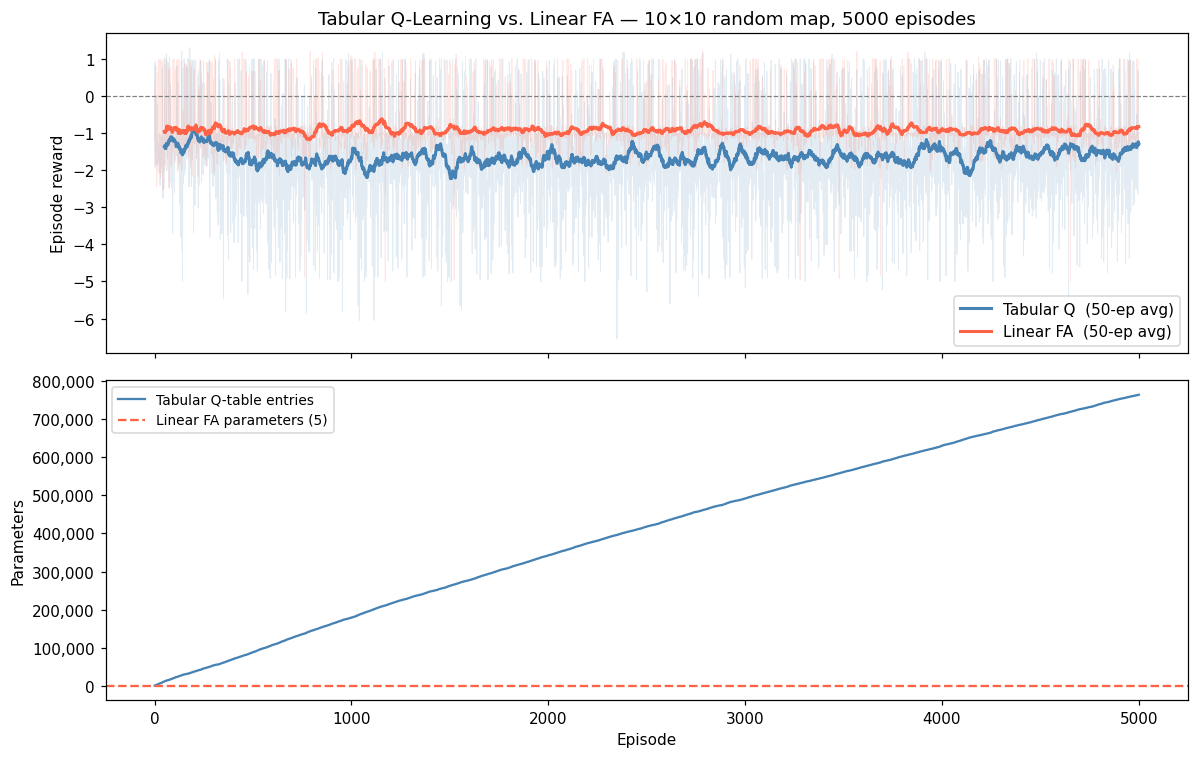

Tabular  last-100 avg reward: -1.3465
Linear FA last-100 avg reward: -0.8785
Tabular Q-table entries: 764,370
Linear FA parameters:    5


In [4]:
episodes = np.arange(1, N_TRAIN + 1)
kernel   = np.ones(SMOOTH) / SMOOTH

q_smooth  = np.convolve(q_rewards,  kernel, mode='valid')
fa_smooth = np.convolve(fa_rewards, kernel, mode='valid')
x_smooth  = episodes[SMOOTH - 1:]

fig, (ax_r, ax_q) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# ── Reward panel ──────────────────────────────────────────────────────────────
ax_r.plot(episodes, q_rewards,
          alpha=0.15, color='steelblue', linewidth=0.6)
ax_r.plot(episodes, fa_rewards,
          alpha=0.15, color='tomato', linewidth=0.6)
ax_r.plot(x_smooth, q_smooth,
          color='steelblue', linewidth=2.0, label=f'Tabular Q  ({SMOOTH}-ep avg)')
ax_r.plot(x_smooth, fa_smooth,
          color='tomato',    linewidth=2.0, label=f'Linear FA  ({SMOOTH}-ep avg)')
ax_r.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_r.set_ylabel('Episode reward')
ax_r.legend(loc='lower right', fontsize=10)
ax_r.set_title(
    f'Tabular Q-Learning vs. Linear FA — {GRID}×{GRID} random map, {N_TRAIN} episodes',
    fontsize=12,
)

# ── Q-table size panel ────────────────────────────────────────────────────────
ax_q.plot(episodes, q_table_sizes, color='steelblue', linewidth=1.5,
          label='Tabular Q-table entries')
ax_q.axhline(N_FEATURES, color='tomato', linewidth=1.5, linestyle='--',
             label=f'Linear FA parameters ({N_FEATURES})')
ax_q.set_ylabel('Parameters')
ax_q.set_xlabel('Episode')
ax_q.legend(fontsize=9)
ax_q.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

print(f'Tabular  last-100 avg reward: {float(np.mean(q_rewards[-100:])):+.4f}')
print(f'Linear FA last-100 avg reward: {float(np.mean(fa_rewards[-100:])):+.4f}')
print(f'Tabular Q-table entries: {agent_q.q_table_size:,}')
print(f'Linear FA parameters:    {N_FEATURES}')

## 3. Learned weight interpretation

Linear FA converges to a weight vector `theta` that is interpretable by construction.

| Index | Feature             | Expected sign | Interpretation |
|-------|---------------------|---------------|----------------|
| 0     | `wall_ahead`        | −             | Blocking actions lead to wall-bump penalties |
| 1     | `goal_visible`      | +             | Seeing the goal signals high nearby return |
| 2     | `energy_level`      | −             | More energy = more −0.01 step costs ahead |
| 3     | `energy_pickup_vis` | +             | A visible pickup extends the episode |
| 4     | `step_progress`     | −             | Further into the episode = fewer future returns |

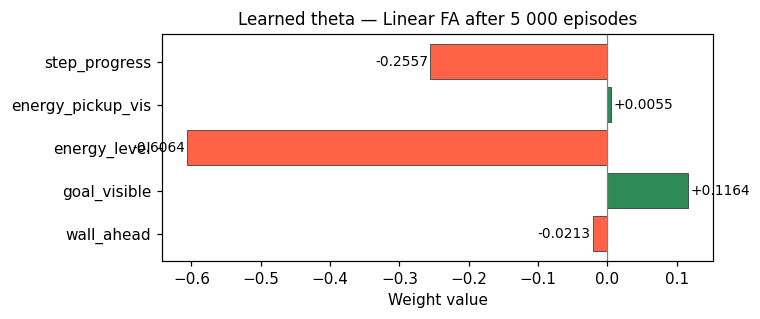

In [5]:
feature_names = [
    'wall_ahead',
    'goal_visible',
    'energy_level',
    'energy_pickup_vis',
    'step_progress',
]

theta = agent_fa.weights
colors = ['tomato' if w < 0 else 'seagreen' for w in theta]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(feature_names, theta, color=colors, edgecolor='#333', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Weight value')
ax.set_title('Learned theta — Linear FA after 5 000 episodes', fontsize=11)
for bar, val in zip(bars, theta):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
    )
plt.tight_layout()
plt.show()